# Technical Analysis Investment Strategy

This is a long-only trend-following strategy. It operates over medium-term time-horizons, and is based on two technical indicators: 
- Kaufmann Adaptive Moving Average (KAMA)  
- Average Directional Momentum Index (ADX and DI)

I've implemented this strategy using [vector-bt pro](https://vectorbt.pro/), a vectorized backtesting framework to determine the indicator parameters that yield the best portfolios (maximimum returns, minimum risk). I've also implemented a multithreaded backtesting pipeline using [Numba](https://numba.pydata.org/), a Just-in-Time (JIT) compiler for Python specifically designed to optimize numerical computations. This pipeline calculates the sharpe and omega ratios for portfolios resulting from different parameter combinations (these parameters feed into the technical indicators which generate trading signals).  

Even though this strategy should not be used alone, it provides a basis to both:  
<b>A)</b> Add more technical indicators to increase robustness, while avoiding overfitting  
<b>B)</b> Generate buy/sell signals which can be used as an input in a machine learning model 


In [1]:
from vectorbtpro import *
import os

from zoneinfo import ZoneInfo
from datetime import datetime
from dateutil.relativedelta import relativedelta

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
vbt.settings.set_theme("dark")

## Setup

Retrieve market data for three assets (BTCUSD, ETHUSD) using YahooFinance's free API, and save the price-series locally. We will examine price-series going back 2 years on three cryptocurrencies, four tech-stocks, whilst using the S&P 500 ETF Trust, Investico QQQ ETF Trust (tracks the NASDAQ 100 index) as benchmarks for comparisons.

In [3]:
os.environ["TZ"] = "UTC"
END_DATE = datetime.now(ZoneInfo("UTC")).strftime("%Y-%m-%d")
START_DATE = (datetime.now(ZoneInfo("UTC")) - relativedelta(years=2)).strftime("%Y-%m-%d")

In [4]:
cryptos = vbt.YFData.pull(
    ["BTC-USD", "ETH-USD", "SOL-USD"],
    start=START_DATE,
    end=END_DATE,
    timeframe="1 day",
    tz_convert="UTC",
    tz_localize="UTC",
    
)

stocks = vbt.YFData.pull(
    ["TSLA", "AAPL", "MSFT", "NVDA"],
    start=START_DATE,
    end=END_DATE,
    timeframe="1 day",
    tz_convert="UTC",
    missing_index="NaN",
    tz_localize="UTC",
)

market_data = stocks.realign(ffill=True)
market_data = market_data.merge(cryptos).dropna()

In [5]:
benchmarks = vbt.YFData.pull(
    ["QQQ", "SPY"],
    start=START_DATE,
    end=END_DATE,
    timeframe="1 day",
    tz="UTC"
)
bm_close = benchmarks.get('Close')
bm_close.index = bm_close.index.normalize() # remove market close timestamp

In [79]:
def calc_returns(x : pd.Series) -> pd.Series:
    ret = (x.diff() / x.shift(1)).dropna()
    return ret

## Technical Indicators

The core logic for both technical indicators is implemented in Numba (@njit decorator) to accelerate backtesting. Both indicators are manually built using NumPy, because pre-packaged libraries such as [ta-lib](https://ta-lib.org/) are considered Python objects which are incompatible with Numba's compilation process.

### Average Directional Momentum Index (ADX)

Given date $t$ in the price-series' duration,  
$ \textbf{up\_move} = \text{high}[t] - \text{high}[t-1] $  
$ \textbf{down\_move} = \text{low}[t] - \text{low}[t-1] $

We calculate the directional momentum, the plus and minus directional indicies, and the ADX:  
(MA = moving average, ATR = average true range)  
<b>Note:</b> Different moving averages are used for the ADX calculation and the +/-DI calculation 
$$
\begin{align*}
\text{+DM} &=
\begin{cases}
\textbf{up\_move} & \text{if} \quad (\textbf{up\_move} > \text{down\_move}) \land (\textbf{up\_move} > 0) \\
0 & \text{otherwise}
\end{cases}\\\\
\text{-DM} &=
\begin{cases}
\textbf{down\_move} & \text{if} \quad (\textbf{down\_move} > \text{up\_move}) \land (\textbf{down\_move} > 0) \\
0 & \text{otherwise}
\end{cases}\\\\
\text{+DI} &= 100 \times \frac{\text{MA}_N(+DM)}{\text{ATR}_N} \\\\
\text{-DI} &= 100 \times \frac{\text{MA}_N(-DM)}{\text{ATR}_N} \\\\
\text{ADX} &= 100 \times \text{MA}_M\left(\frac{\lvert (\text{+DI}) - (\text{-DI}) \rvert}{(\text{+DI}) + (\text{-DI})}\right)
\end{align*}
$$

> The ADX does not indicate trend direction or momentum, only trend strength. It is a lagging indicator.  
> The value of the ADX is proportional to the slope of the trend.  
> -- [Wikipedia](https://en.wikipedia.org/wiki/Average_directional_movement_index)

In [6]:
@njit
def get_atr(high, low, close, period):
    close_shifted_1 = np.roll(close, 1)
    close_shifted_1[0] = np.nan
    
    tr0 = np.abs(high - low)
    tr1 = np.abs(high - close_shifted_1)
    tr2 = np.abs(low - close_shifted_1)
    tr = np.maximum(np.maximum(tr0, tr1), tr2)
    atr = vbt.nb.wwm_mean_1d_nb(tr, period)  

    # Wilder's EWMA
    alpha = 1 / period
    weights = (1 - alpha) ** np.arange(period - 1, -1, -1)  
    weights /= weights.sum()
    ewma = np.convolve(tr, weights, mode='full')[:len(close)] 
    ewma[:period - 1] = np.nan  

    return atr

@njit
def get_dm(high, low):
    high_shifted_1 = np.roll(high, 1)
    high_shifted_1[0] = np.nan
    plus_dm_cmp = high_shifted_1 - high
    plus_dm = np.where(plus_dm_cmp > 0, plus_dm_cmp, 0)
    
    low_shifted_1 = np.roll(low, 1)
    low_shifted_1[0] = np.nan
    minus_dm_cmp = low_shifted_1 - low
    minus_dm = np.where(minus_dm_cmp > 0, minus_dm_cmp, 0)
    return plus_dm, minus_dm

@njit
def get_adx_di(high, low, close, di_ma_len, adx_ma_len):
    plus_dm, minus_dm = get_dm(high, low)
    atr = get_atr(high, low, close, di_ma_len)
     
    conv_arr = np.ones(di_ma_len, dtype=np.float64)
    plus_dm_sma = np.convolve(plus_dm, conv_arr, 'full')[:-(di_ma_len-1)] / di_ma_len
    minus_dm_sma = np.convolve(minus_dm, conv_arr, 'full')[:-(di_ma_len-1)] / di_ma_len
    
    plus_di = 100 * (plus_dm_sma / atr)
    minus_di = 100 * (minus_dm_sma / atr)
    res = np.abs(plus_di - minus_di) / plus_di + minus_di

    conv_arr = np.ones(adx_ma_len, dtype=np.float64)
    adx = np.convolve(res, conv_arr, 'full')[:-(adx_ma_len-1)] / adx_ma_len
    
    return adx, plus_di, minus_di

The following code creates an vector-bt indicator from the Numba-accelerated functions above. This indicator class is versatile and can be used outside of the accelerated pipeline to analyze and evaluate the performance of this indicator using member functions native to vector-bt.

In [7]:
ADX = vbt.IF(
    class_name = 'Average Directional Momentum Index',
    short_name = 'ADX',
    input_names = ['high', 'low', 'close'], 
    param_names = ['di_ma_len', 'adx_ma_len'],
    output_names = ['adx', 'plus_di', 'minus_di']
).with_apply_func(
    get_adx_di,
    takes_1d=True,
    di_ma_len=14,
    adx_ma_len=20
)

In [8]:
vbt.phelp(ADX.run)

Average Directional Momentum Index.run(
    high,
    low,
    close,
    di_ma_len=Default(value=14),
    adx_ma_len=Default(value=20),
    short_name='ADX',
    hide_params=None,
    hide_default=True,
    **kwargs
):
    Run `Average Directional Momentum Index` indicator.
    
    Inputs:
        * `high`
        * `low`
        * `close`
    
    Parameters:
        * `di_ma_len`
        * `adx_ma_len`
    
    Outputs:
        * `adx`
        * `plus_di`
        * `minus_di`
    
    Pass a list of parameter names as `hide_params` to hide their column levels, or `True` to hide all.
    Set `hide_default` to False to display column levels for parameters with default values.
    
    Args:
        *args: Positional arguments corresponding to inputs, parameters, and in-place outputs.
        **kwargs: Keyword arguments for `Average Directional Momentum Index.run_pipeline`.
    
    Returns:
        Indicator: Instance of the `Average Directional Momentum Index` indicator, or a tuple 

In [9]:
class ADX(ADX):
    def plot(self,
             column=None,
             high_kwargs=None,
             low_kwargs=None,
             close_kwargs=None,
             plus_di_kwargs=None,
             minus_di_kwargs=None,
             adx_kwargs=None):
        high_kwargs = high_kwargs if high_kwargs else {}
        low_kwargs = low_kwargs if low_kwargs else {}
        close_kwargs = close_kwargs if close_kwargs else {}
        
        plus_di_kwargs = plus_di_kwargs if plus_di_kwargs else {}
        minus_di_kwargs = minus_di_kwargs if minus_di_kwargs else {}
        adx_kwargs = adx_kwargs if adx_kwargs else {}

        close = self.select_col_from_obj(self.close, column).rename('Close')
        plus_di = self.select_col_from_obj(self.plus_di, column).rename('Plus DI')
        minus_di = self.select_col_from_obj(self.minus_di, column).rename('Minus DI')
        adx = self.select_col_from_obj(self.adx, column).rename('ADX')

        fig = make_subplots(rows=2, cols=1,
                    shared_xaxes=True,
                    vertical_spacing=0.02)

        fig.add_trace(
            go.Scatter(x=close.index,
                       y=close.values, 
                       name="Close",
                       **close_kwargs),
            row=1, col=1
        )
        
        fig.add_trace(
            go.Scatter(x=adx.index,
                       y=adx.values, 
                       name="ADX",
                       **adx_kwargs),
            row=2, col=1
        )
        fig.add_trace(
            go.Scatter(x=plus_di.index,
                       y=plus_di.values, 
                       name="+DI",
                       **plus_di_kwargs),
            row=2, col=1
        )
        fig.add_trace(
            go.Scatter(x=minus_di.index,
                       y=minus_di.values, 
                       name="-DI",
                       **minus_di_kwargs),
            row=2, col=1
        )
        
        
        fig.update_layout(height=600, width=1000)
        
        return fig
        

In [10]:
adx = ADX.run(market_data.get('High'), market_data.get('Low'), market_data.get('Close'))

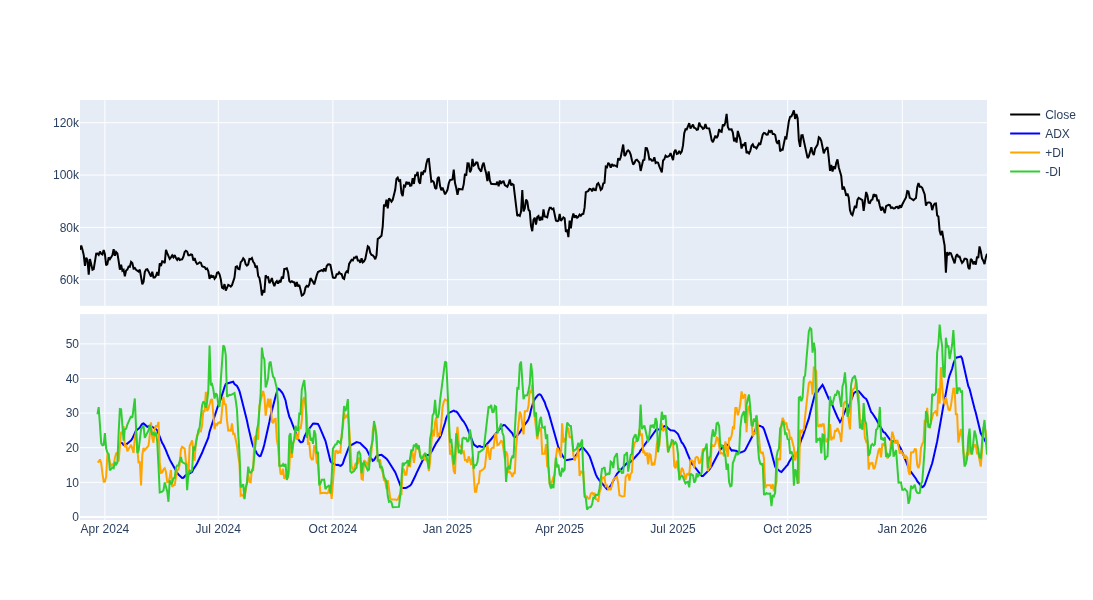

In [11]:
fig1 = adx.plot(column='BTC-USD',
         close_kwargs=dict(line_color='black'),
         adx_kwargs=dict(line_color='blue'),
         plus_di_kwargs=dict(line_color='orange'),
         minus_di_kwargs=dict(line_color='limegreen')
        )
#fig1.write_html("fig1.html", include_plotlyjs="embed")
fig1.show()

### Kaufmann Adaptive Moving Average (KAMA)

$$
\begin{align*}
\text{KAMA} &= \text{KAMA}_{i-1} + \text{sc}(\text{close} - \text{KAMA}_{i-1}) \\
\text{sc} &= ((\text{ER}_i \times (\text{fastest\_sc} - \text{slowest\_sc})) + \text{slowest\_sc})^2
\end{align*}
$$  

$$
\text{fastest\_sc} = \frac{2}{\text{fast MA period}+1}
$$
$$
\text{slowest\_sc} = \frac{2}{\text{slow MA period}+1}
$$
$$
\text{ER}_i = \frac{\lvert \text{close}_i - \text{close}_{i-n} \rvert}{\sum_{j=i-n}^i \lvert \text{close}_j - \text{close}_{j-1} \rvert}
$$
$$
n = \text{number of periods}
$$




> Kaufman’s Adaptive Moving Average can also be used to spot the beginning of new trends and pinpoint trend reversal points. One way to do this is by plotting two KAMA lines on a chart – one with a more short-term moving average and another with a longer-term moving average. When a faster KAMA line crosses above a slower KAMA line, this indicates a change from a downtrend to an uptrend.  
> - [Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/career-map/sell-side/capital-markets/kaufmans-adaptive-moving-average-kama/)

In [12]:
@njit
def get_sc(close, period, fast_ma_len, slow_ma_len):
    fastest_sc = 2 / (fast_ma_len + 1)
    slowest_sc = 2 / (slow_ma_len + 1)

    price_shifted_1 = np.roll(close,1)
    price_shifted_1[0] = np.nan
    diff_close = np.abs(close - price_shifted_1)

    conv_arr = np.ones(period,dtype=np.float64)
    denominator = np.convolve(diff_close, conv_arr, 'full')[:-(period-1)] 

    price_shifted_period = np.roll(close,period)
    price_shifted_period[0:period] = np.nan
    
    ER = np.abs(close - price_shifted_period) / denominator
    sc = (ER * (fastest_sc - slowest_sc) + slowest_sc) ** 2
    return sc

@njit
def get_kama(close, period, fast_ma_len, slow_ma_len):
    sc = get_sc(close, period, fast_ma_len, slow_ma_len)
    kama = np.full((close.shape[0]), np.nan)
    for i in range(1,close.shape[0]):  
        if not np.isnan(sc[i]):
            if np.isnan(kama[i-1]):
                kama[i-1] = close[0]
            kama[i] = kama[i-1] + (sc[i] * (close[i] - kama[i-1]))
        else:
            kama[i] = np.nan
    return kama


In [13]:
Kama = vbt.IF(
    class_name = 'Kaufmann Adaptive Moving Average',
    short_name = 'KAMA',
    input_names = ['close'], 
    param_names = ['period', 'fast_ma_len', 'slow_ma_len'],
    output_names = ['kama']
).with_apply_func(
    get_kama,
    takes_1d=True,
    period=10,
    fast_ma_len=2,
    slow_ma_len=30
)

In [14]:
vbt.phelp(Kama.run)

Kaufmann Adaptive Moving Average.run(
    close,
    period=Default(value=10),
    fast_ma_len=Default(value=2),
    slow_ma_len=Default(value=30),
    short_name='KAMA',
    hide_params=None,
    hide_default=True,
    **kwargs
):
    Run `Kaufmann Adaptive Moving Average` indicator.
    
    Inputs:
        * `close`
    
    Parameters:
        * `period`
        * `fast_ma_len`
        * `slow_ma_len`
    
    Outputs:
        * `kama`
    
    Pass a list of parameter names as `hide_params` to hide their column levels, or `True` to hide all.
    Set `hide_default` to False to display column levels for parameters with default values.
    
    Args:
        *args: Positional arguments corresponding to inputs, parameters, and in-place outputs.
        **kwargs: Keyword arguments for `Kaufmann Adaptive Moving Average.run_pipeline`.
    
    Returns:
        Indicator: Instance of the `Kaufmann Adaptive Moving Average` indicator, or a tuple of additional objects if applicable.


In [15]:
class Kama(Kama):
    def plot(self,
             column=None,
             close_kwargs=None,
             kama_kwargs=None,
             fig=None,
             **layout_kwargs
            ):
        close_kwargs = close_kwargs if close_kwargs else {}
        kama_kwargs = kama_kwargs if kama_kwargs else {}

        close = self.select_col_from_obj(self.close, column).rename('Close')
        kama = self.select_col_from_obj(self.kama, column).rename('Kama')

        fig = close.vbt.plot(fig=fig, **close_kwargs, **layout_kwargs)
        kama.vbt.plot(fig=fig, **kama_kwargs)

        return fig

In [16]:
kama = Kama.run(market_data.get('Close'))

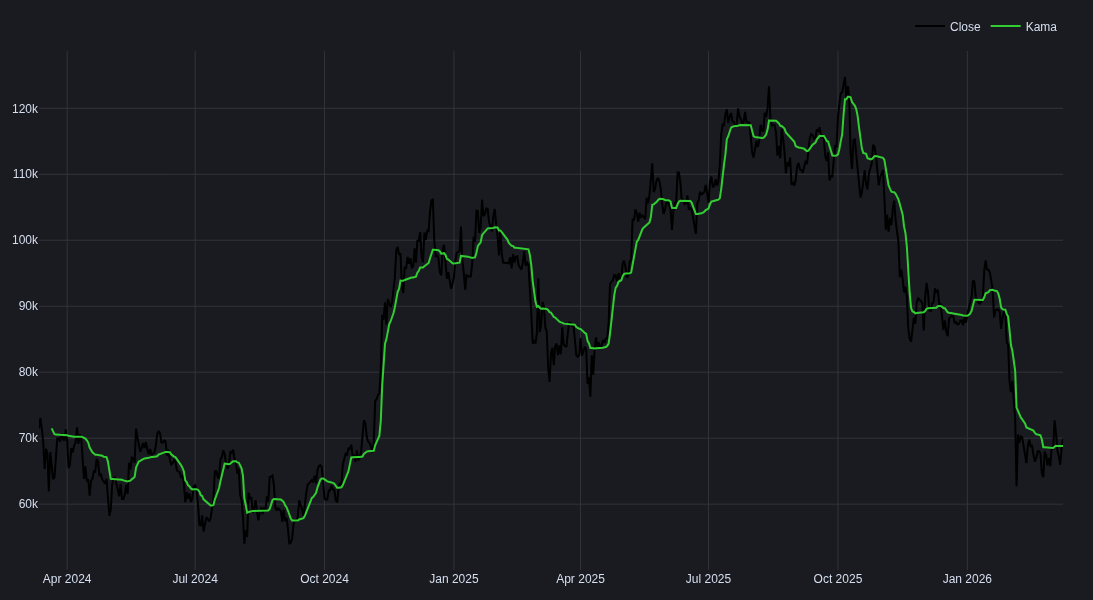

In [17]:
fig2 = kama.plot(column='BTC-USD',
          close_kwargs=dict(trace_kwargs=dict(line_color='black')),
          kama_kwargs=dict(trace_kwargs=dict(line_color='limegreen'))
         )
fig2.update_layout(height=600, width=1000)
#fig2.write_html("fig2.html", include_plotlyjs="embed")
fig2.show()

## Signals Development

This strategy generates a buy signal on an upwards trend change (faster KAMA crossing <b>above</b> slower KAMA) and a sell signal on a downwards trend change (faster KAMA crossing <b>below</b> slower KAMA). The ADX is used as a filter, removing buy or sell signals if below a certain threshold (i.e. the trend is not strong enough).

In [18]:
@njit(nogil=True)
def generate_signals(kama_fast, kama_slow, adx, adx_thrsh):
    "Takes only one asset column, iterate in caller"
    entries = vbt.nb.crossed_above_1d_nb(kama_fast, kama_slow) 
    exits = vbt.nb.crossed_below_1d_nb(kama_fast, kama_slow)

    adx_filter = np.where(adx > adx_thrsh, 1.0, 0.0)
    entries = entries * adx_filter
    exits = exits * adx_filter

    # Ensure the strategy starts only after the first exit signal
    started = False  
    long = False     
    short = False    
    new_entries = np.full(kama_fast.shape[0], False, dtype=np.bool_)
    new_exits = np.full(kama_fast.shape[0], False, dtype=np.bool_)

    for i in range(entries.size):
        if not started:
            if exits[i]:  # Wait for the first exit signal
                started = True
                long = False
                short = True
                new_exits[i] = True
            continue  # Skip all other signals until the strategy starts
    
        # After the first exit, alternate between long and short
        if short and entries[i]:  # Flip to long
            short = False
            long = True
            new_entries[i] = True
        elif long and exits[i]:  # Flip to short
            long = False
            short = True
            new_exits[i] = True
    
    return (new_entries, new_exits)

In [24]:
def get_signals_analysis(kama_fast, kama_slow, adx, adx_thrsh):
    dim = market_data.get('Close').shape
    column_names = market_data.get('Close').columns
    long_entries = np.empty(dim, dtype=np.bool_)
    long_exits = np.empty(dim, dtype=np.bool_)
    
    for col in range(dim[1]):
        column_name= column_names[col]
        signals = generate_signals(kama_fast.kama.values[:, col], 
                                   kama_slow.kama.values[:, col], 
                                   adx.adx.values[:, col],
                                   adx_thrsh)
        
        long_entries[:, col] = signals[0]
        long_exits[:, col] = signals[1]
    
    return (long_entries, long_exits)

### Pre-Analysis

This stage is used to "debug" the signals generated in the stage right before. Some buy/sell signals should not be converted into orders; these signals are caught and filtered here.

In [20]:
def plot_signals(data, symbol, signals): 
    fig = data.plot(
        symbol=symbol, 
        ohlc_trace_kwargs=dict(opacity=0.5), 
        plot_volume=False
    )

    entries = pd.DataFrame(signals[0], columns=data.columns, index=data.index)
    exits = pd.DataFrame(signals[1], columns=data.columns, index=data.index)
    
    entries[symbol].vbt.signals.plot_as_entries(y=data.get("Close", symbol), fig=fig)
    exits[symbol].vbt.signals.plot_as_exits(y=data.get("Close", symbol), fig=fig)
    
    fig.update_layout(height=600, width=1100)
    return fig

In [22]:
kama_fast = Kama.run(market_data.get('Close'), period=5)
kama_slow = Kama.run(market_data.get('Close'), period=10)

In [25]:
entries, exits, = get_signals_analysis(kama_fast, kama_slow, adx, 9)
signals = (entries, exits)

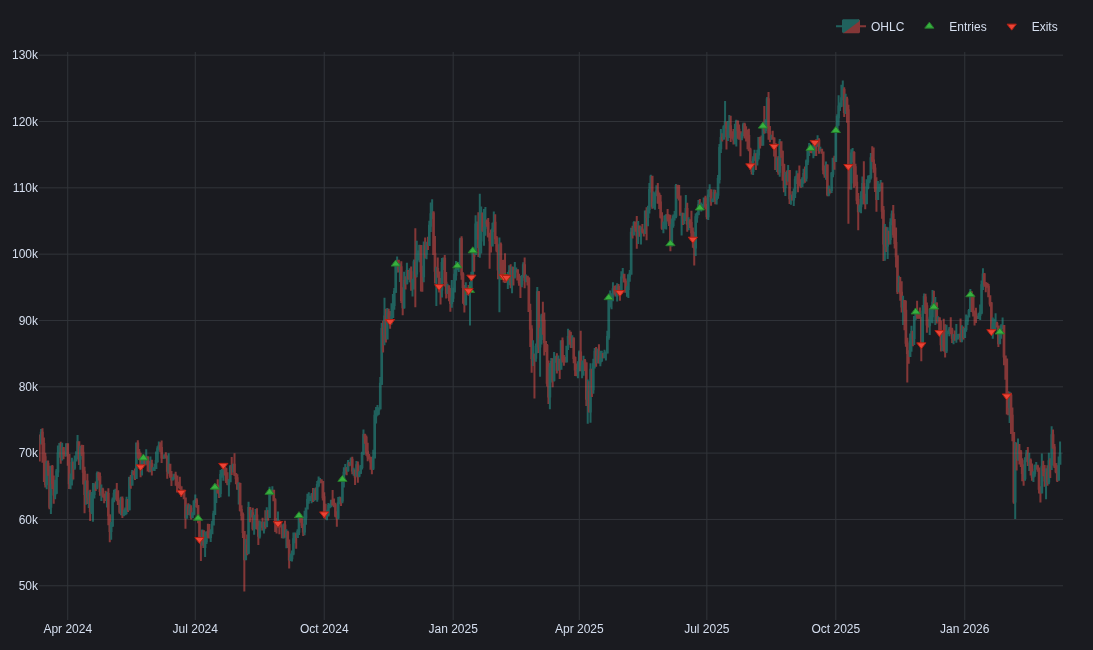

In [27]:
fig3 = plot_signals(market_data, 'BTC-USD', signals)
fig3.update_layout(height=650, width=1000)
#fig3.write_html("fig3.html", include_plotlyjs="embed")
fig3.show()

At first glance, this strategy looks decent. Since this is a trend-following strategy, some whiplash is to be expected in ranging market conditions. 
However, the default indicator values yields a strategy that captures major trends - this is exactly where the KAMA and ADX excel. 

## Backtesting

### Parameter Space

Let's define a parameter space $S$ for both the KAMA and the ADX indicators. Here $S$ is the cartesian product of all input parameter sets.

In [28]:
kama_fast_period = np.arange(3, 15)
kama_slow_period = np.arange(15, 30)
di_ma_len = np.arange(2, 10)
adx_ma_len = np.arange(3, 15)
adx_thrsh = np.arange(10, 40, 2)

In [29]:
op_tree = (product, 
           kama_fast_period, 
           kama_slow_period, di_ma_len, adx_ma_len, adx_thrsh)
param_products = vbt.generate_param_combs(op_tree) 

kama_fast_period_prod = np.asarray(param_products[0])
kama_slow_period_prod = np.asarray(param_products[1])
di_ma_len_prod = np.asarray(param_products[2])
adx_ma_len_prod = np.asarray(param_products[3])
adx_thrsh_prod = np.asarray(param_products[4])

In [30]:
kama_fast_period_prod.size

259200

### Pipeline

Let's define a pipeline which:
1. Generates trading signals based on a given parameter combination $p\in S$
2. Creates a portfolio $P$ based on the generated trading signals 
3. Calculates the Sharpe ratio and counts the number of sell orders for portfolio $P$

The <u>nogil=True</u> argument in the @njit decorator allows the Python Global Interpreter Lock (GIL) to be released during computation, enabling the execution of independent tasks across multiple threads simultaneously. Dask then partitions the workload into manageable tasks and schedules them across the cores. Each task computes portfolios for a mutually-exclusive subset of parameter space $S$. Overall, this chunked pipeline leverages both Numba's JIT compilation for per-portfolio calculations and Dask's distributed execution capabilities for multi-core parallelism. 

In [43]:
@njit(nogil=True)
def pipeline_nb(high, low, close, 
                kama_fast_period=np.asarray([5]), 
                kama_slow_period=np.asarray([10]), 
                di_ma_len=np.asarray([14]),
                adx_ma_len=np.asarray([20]),
                adx_thrsh=np.asarray([9]),
                ann_factor=365):

    num_metrics = 4
    num_param_comb = kama_fast_period.size
    metrics = np.empty((num_param_comb * close.shape[1], num_metrics), dtype=np.float64)
    
    long_entries = np.empty(close.shape, dtype=np.bool)
    long_exits = np.empty(close.shape, dtype=np.bool)
    group_lens = np.full(close.shape[1], 1)
    k = 0

    for i in range(num_param_comb):
        for col in range(close.shape[1]): # for each asset
 
            kama_fast = get_kama(close[:, col], kama_fast_period[i], 2, 30)
            kama_slow = get_kama(close[:, col], kama_slow_period[i], 2, 30)
            adx_line, _, _ = get_adx_di(high[:, col], low[:, col], close[:, col], di_ma_len[i], adx_ma_len[i])
            
            signals = generate_signals(kama_fast, kama_slow, adx_line, adx_thrsh[i])
        
            long_entries[:, col] = signals[0]
            long_exits[:, col] = signals[1]

        sim_out = vbt.pf_nb.from_signals_nb(
            target_shape=close.shape,
            group_lens=group_lens,
            close=close,
            long_entries=long_entries,
            long_exits=long_exits,
            save_returns=True
        )
        num_trades = long_exits.sum(axis=0)
        
        returns = sim_out.in_outputs.returns
        sharpe = vbt.ret_nb.sharpe_ratio_nb(returns, ann_factor, ddof=1)
        sortino = vbt.ret_nb.sortino_ratio_nb(returns, ann_factor)
        dd = vbt.ret_nb.max_drawdown_nb(returns, ann_factor)

        metrics_vec = np.column_stack((sharpe, sortino, dd, num_trades))
        metrics_vec_len = len(metrics_vec)
        
        metrics[k:k + metrics_vec_len] = metrics_vec
        k += metrics_vec_len
            
    return metrics

Let's run the backtesting pipeline on the default values for the KAMA and ADX indicators.  
The resulting columns are: \[sharpe, omega, downside deviation, number of trades\]

In [44]:
ann_factor = vbt.pd_acc.returns.get_ann_factor(freq='1d')
pipeline_nb(market_data.get('Close').values, market_data.get('High').values, market_data.get('Low').values, ann_factor=ann_factor)

array([[ 1.50583401e-01,  2.05265463e-01, -4.82387191e-01,
         2.60000000e+01],
       [ 5.94725786e-01,  8.12821760e-01, -2.16020867e-01,
         2.90000000e+01],
       [-1.58806669e-02, -2.09265048e-02, -1.85583227e-01,
         2.70000000e+01],
       [ 5.26891380e-01,  7.07789378e-01, -4.24238505e-01,
         2.60000000e+01],
       [ 1.53453154e-01,  2.09953885e-01, -3.16946099e-01,
         2.10000000e+01],
       [ 3.07945937e-01,  4.32116111e-01, -4.17823558e-01,
         1.90000000e+01],
       [-4.56551447e-01, -6.12638647e-01, -5.03775891e-01,
         2.90000000e+01]])

So, despite the reasonable distribution of trades in pre-analysis, the default parameters for the ADX & DI and the KAMA are actually leading to a portfolio that loses money for Bitcoin and Ethereum. We'll have to pick better ones, which is where the multithreaded chunked pipeline comes in.

In [45]:
def merge_func(arrs, ann_args, input_columns):
    arr = np.concatenate(arrs)

    param_idx = vbt.stack_indexes((
        pd.Index(ann_args['kama_fast_period']['value'], name='kama_fast_period'),
        pd.Index(ann_args['kama_slow_period']['value'], name='kama_slow_period'),
        pd.Index(ann_args['di_ma_len']['value'], name='di_ma_len'),
        pd.Index(ann_args['adx_ma_len']['value'], name='adx_ma_len'),
        pd.Index(ann_args['adx_thrsh']['value'], name='adx_thrsh')
    ))

    idx = vbt.combine_indexes((
        param_idx,
        input_columns
    ))
    
    return pd.DataFrame(arr, columns=['Sharpe', 'Sortino', 'DD', 'Num Trades'], index=idx)

In [46]:
nb_chunked = vbt.chunked(
    size=vbt.ArraySizer(arg_query='kama_fast_period', axis=0),
    arg_take_spec=dict(
        high=None,
        low=None,
        close=None,
        kama_fast_period=vbt.ArraySlicer(axis=0), 
        kama_slow_period=vbt.ArraySlicer(axis=0), 
        adx_ma_len=vbt.ArraySlicer(axis=0), 
        di_ma_len=vbt.ArraySlicer(axis=0), 
        adx_thrsh=vbt.ArraySlicer(axis=0), 
        ann_factor=None
    ),
    merge_func=merge_func,
    merge_kwargs=dict(
        ann_args=vbt.Rep("ann_args")
    )
)

In [47]:
chunked_pipeline_nb = nb_chunked(pipeline_nb)

In [48]:
res = chunked_pipeline_nb(
    market_data.get('High').values, market_data.get('Low').values, market_data.get('Close').values,
    kama_fast_period=kama_fast_period_prod, 
    kama_slow_period=kama_slow_period_prod, 
    adx_ma_len=adx_ma_len_prod,
    adx_thrsh=adx_thrsh_prod,
    di_ma_len=di_ma_len_prod,
    ann_factor=ann_factor,
    _execute_kwargs=dict(engine="dask"),
    _merge_kwargs=dict(input_columns=market_data.get('Close').columns)
)

## Analysis

The objective of the backtest was to determine the portfolio strategy that places a minimum number of trades and yields highest Sharpe ratio.

In [56]:
res = res[res['DD'] > -0.30] 
res = res[res['Num Trades'] > 15] 
best_portfolios = res.sort_values(by=['Sortino'], ascending=False)
best_portfolios.head(20)

Sharpe  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol             
10               15               9         9          10        NVDA    1.852796   
13               15               9         13         12        NVDA    1.752530   
10               15               9         8          10        NVDA    1.740339   
13               15               9         12         10        NVDA    1.674107   
                                  4         5          10        NVDA    1.641592   
3                17               9         4          10        TSLA    1.538313   
13               15               6         3          14        NVDA    1.666755   
10               15               9         6          10        NVDA    1.665934   
                                            7          10        NVDA    1.665934   
13               15               8         13         12        NVDA    1.618298   
                                  6         5          12        NVDA    1.578235   
                                  9         11         10        NVDA    1.588901   
                                            12         14        NVDA    1.600827   
                                            13         14        NVDA    1.600827   
10               15               9         7          12        NVDA    1.576026   
13               15               5         5          12        NVDA    1.500495   
10               15               9         10         10        NVDA    1.546142   
13               15               7         3          12        NVDA    1.477716   
                                            4          12        NVDA    1.477716   
10               15               9         5          10        NVDA    1.532236   

                                                                          Sortino  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol             
10               15               9         9          10        NVDA    3.159087   
13               15               9         13         12        NVDA    2.934808   
10               15               9         8          10        NVDA    2.867687   
13               15               9         12         10        NVDA    2.850307   
                                  4         5          10        NVDA    2.790250   
3                17               9         4          10        TSLA    2.742193   
13               15               6         3          14        NVDA    2.740393   
10               15               9         6          10        NVDA    2.731966   
                                            7          10        NVDA    2.731966   
13               15               8         13         12        NVDA    2.673235   
                                  6         5          12        NVDA    2.670603   
                                  9         11         10        NVDA    2.652898   
                                            12         14        NVDA    2.616691   
                                            13         14        NVDA    2.616691   
10               15               9         7          12        NVDA    2.564052   
13               15               5         5          12        NVDA    2.495321   
10               15               9         10         10        NVDA    2.478724   
13               15               7         3          12        NVDA    2.450562   
                                            4          12        NVDA    2.450562   
10               15               9         5          10        NVDA    2.448085   

                                                                               DD  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol             
10               15               9         9          10        NVDA   -0.158006   
13               15               9         13         12        NVDA   -0.233

In [66]:
btc_usd_rows = best_portfolios.loc[pd.IndexSlice[:, :, :, :, :, 'BTC-USD'], :]
btc_usd_best_pf_pos = best_portfolios.index.get_indexer(btc_usd_rows.index)
btc_usd_rows.head(3)

Sharpe  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol              
13               15               4         6          16        BTC-USD  1.106840   
                                  6         4          16        BTC-USD  1.048460   
                                  4         9          18        BTC-USD  0.962355   

                                                                           Sortino  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol              
13               15               4         6          16        BTC-USD  1.804673   
                                  6         4          16        BTC-USD  1.707000   
                                  4         9          18        BTC-USD  1.583545   

                                                                                DD  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol              
13               15               4         6          16        BTC-USD -0.216765   
                                  6         4          16        BTC-USD -0.216765   
                                  4         9          18        BTC-USD -0.146603   

                                                                          Num Trades  
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol               
13               15               4         6          16        BTC-USD        17.0  
                                  6         4          16        BTC-USD        16.0  
                                  4         9          18        BTC-USD        16.0

In [67]:
eth_usd_rows = best_portfolios.loc[pd.IndexSlice[:, :, :, :, :, 'ETH-USD'], :]
eth_usd_best_pf_pos = best_portfolios.index.get_indexer(eth_usd_rows.index)
eth_usd_rows.head(3)

Sharpe  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol              
14               15               3         6          16        ETH-USD  1.232727   
                                            5          14        ETH-USD  1.232727   
                                                       12        ETH-USD  1.232727   

                                                                           Sortino  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol              
14               15               3         6          16        ETH-USD  2.139881   
                                            5          14        ETH-USD  2.139881   
                                                       12        ETH-USD  2.139881   

                                                                                DD  \
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol              
14               15               3         6          16        ETH-USD -0.299735   
                                            5          14        ETH-USD -0.299735   
                                                       12        ETH-USD -0.299735   

                                                                          Num Trades  
kama_fast_period kama_slow_period di_ma_len adx_ma_len adx_thrsh symbol               
14               15               3         6          16        ETH-USD        16.0  
                                            5          14        ETH-USD        16.0  
                                                       12        ETH-USD        16.0

The strategy performed best on NVDA (which is understandable due to its astronomical performance in that time period), but and for the same time eriod the maximum obtainable SR for this strategy on BTC-USD was 1.1, which is quite surprising 

(on ETH-USD the strategy performed slightly better achieving $\text{STR}(x) > 2.13$)

In [75]:
inputs = best_portfolios.iloc[eth_usd_best_pf_pos[0]].name
kama_fast = Kama.run(market_data.get('Close'), period=inputs[0])
kama_slow = Kama.run(market_data.get('Close'), period=inputs[1])
adx = adx.run(market_data.get('High'), market_data.get('Low'), market_data.get('Close'), 
              di_ma_len=inputs[2],
              adx_ma_len=inputs[3])
adx_thrsh= inputs[4]

In [77]:
signals = get_signals_analysis(kama_fast, kama_slow, adx, adx_thrsh)
pf = vbt.Portfolio.from_signals(
    market_data.get('Close'),
    entries=signals[0],
    exits=signals[1]
)

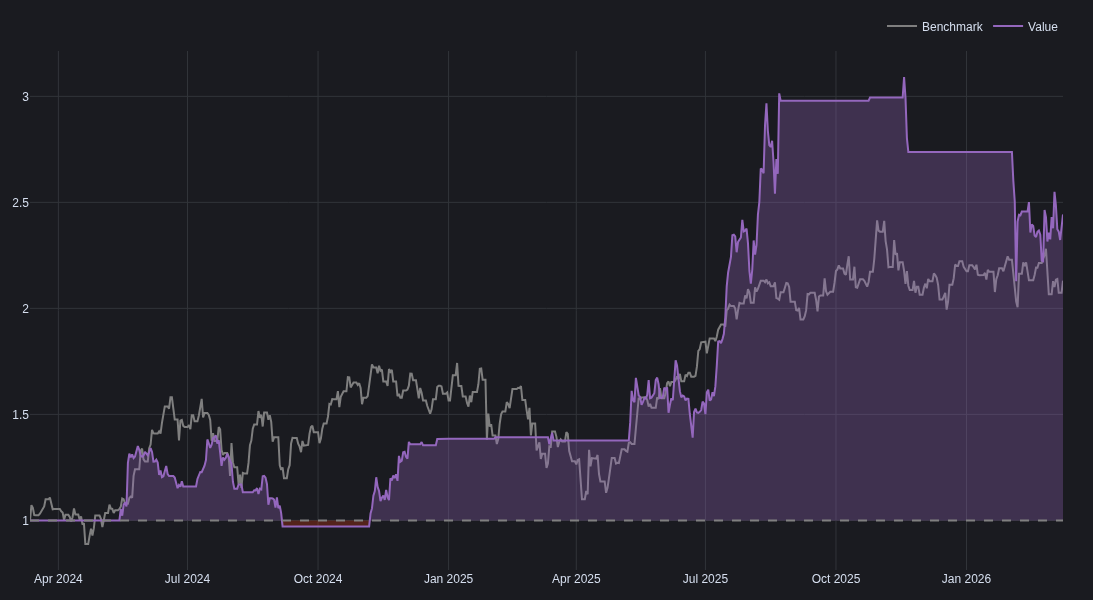

In [96]:
fig = vbt.make_subplots(rows=1, cols=1)
fig.update_layout(width=1000,height=600)
pf.plot_cumulative_returns(column='ETH-USD', 
                          # bm_returns=calc_returns(bm_close['QQQ']),
                          bm_returns=calc_returns(market_data.get('Close')['NVDA']),
                          add_trace_kwargs=dict(row=1, col=1), 
                          fig=fig)

# fig4.update_layout(autosize=True)
# fig4.update_layout(
#     autosize=True,
#     height=None,  # Remove fixed height
#     width=None,   # Remove fixed width
# )
# fig4.write_html("strategy_chart.html")
# html_str = fig4.to_html(include_plotlyjs='cdn', full_html=False, config={"responsive": True})

fig.show()

In [98]:
pf['ETH-USD'].stats()

Start Index                    2024-03-12 00:00:00+00:00
End Index                      2026-03-10 00:00:00+00:00
Total Duration                         729 days 00:00:00
Start Value                                        100.0
Min Value                                      97.152676
Max Value                                     309.153958
End Value                                     244.297168
Total Return [%]                              144.297168
Benchmark Return [%]                          -48.819581
Position Coverage [%]                          37.860082
Max Gross Exposure [%]                             100.0
Max Drawdown [%]                               31.184697
Max Drawdown Duration                  237 days 00:00:00
Total Orders                                          31
Total Fees Paid                                      0.0
Total Trades                                          16
Win Rate [%]                                   46.666667
Best Trade [%]                 

In [39]:
for stat in pf_stats.split('\n'):
    data = stat.split()
    val = data[-1]
    metric = " ".join(data[:-1])
    print(metric, ": ", val)
    

Start Index 2024-04-01 :  00:00:00+00:00
End Index 2025-09-30 :  00:00:00+00:00
Total Duration 548 days :  00:00:00
Start Value :  100.0
Min Value :  95.233233
Max Value :  322.788431
End Value :  251.352673
Total Return [%] :  151.352673
Benchmark Return [%] :  18.285934
Position Coverage [%] :  50.182482
Max Gross Exposure [%] :  100.0
Max Drawdown [%] :  22.13083
Max Drawdown Duration 155 days :  00:00:00
Total Orders :  30
Total Fees Paid :  0.0
Total Trades :  15
Win Rate [%] :  73.333333
Best Trade [%] :  94.820558
Worst Trade [%] :  -13.290034
Avg Winning Trade [%] :  14.936616
Avg Losing Trade [%] :  -8.703298
Avg Winning Trade Duration 16 days :  19:38:10.909090909
Avg Losing Trade Duration 22 days :  12:00:00
Profit Factor :  3.345905
Expectancy :  10.090178
Sharpe Ratio :  1.495811
Calmar Ratio :  3.830033
Omega Ratio :  1.361657
Sortino Ratio :  2.559066
Name: ETHUSD, dtype: :  object


This strategy demonstrates an ability to outperform the benchmark over the evaluation period. It captured major moves from Feb 2024 to Mar 2024, navigated the ranging market from in  experiences a prolonged drawdown from August 2024 to November 2024.
Entries and exits could be better timed at the bottom of the trend, but this which would require more indicators operating on different time horizons. 

Overall, this back-testing system provides a foundation for creating a more robust TA-based investment strategy with a more complex ruleset. To combat the underperformance in ranging or weakly-trending markets, this analysis would include maximum days in drawdown to evaluate strategy performance, and not just downside deviation. Furthermore, this strategy could be combined with a machine learning classification model specifically trained to detect ranging and trending market regimes. Such a model would allow me to pivot between a trend-following strategy and a mean-reversion strategy, effectively trading in both market regimes.